<a href="https://colab.research.google.com/github/NadineAppiah/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)



Running on: cpu


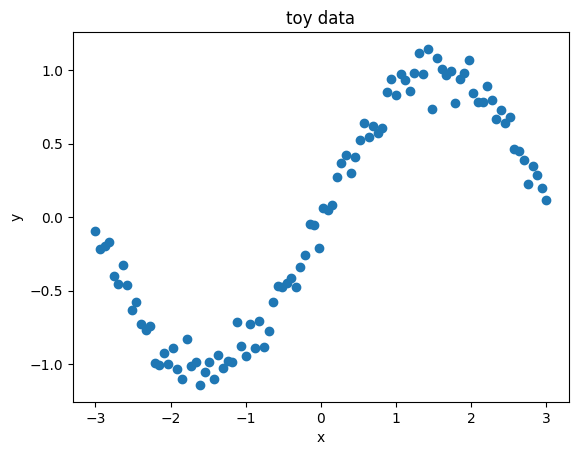

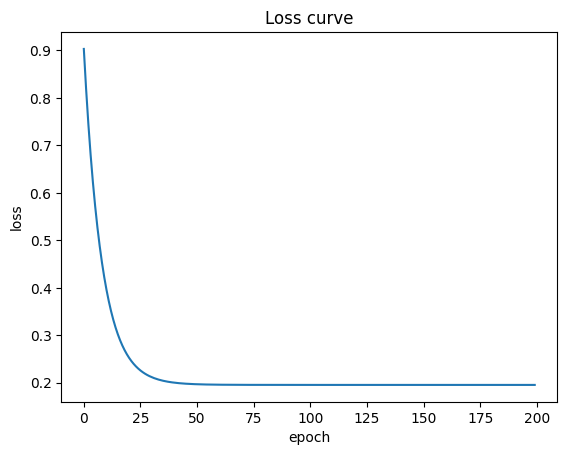

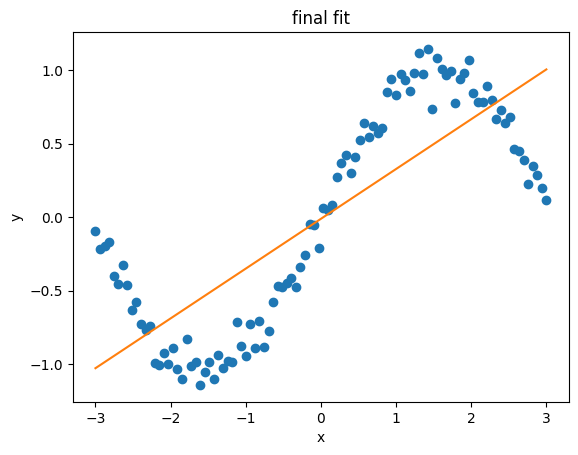

In [17]:
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)
plt.plot(x, y, 'o')
plt.title('toy data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

w = np.random.normal(0, 0.1, 1)
b = np.random.normal(0, 0.1, 1)

lr = 0.01
losses = []
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

plt.plot(losses)
plt.title('Loss curve')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, w * x + b)
plt.title('final fit')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

1. 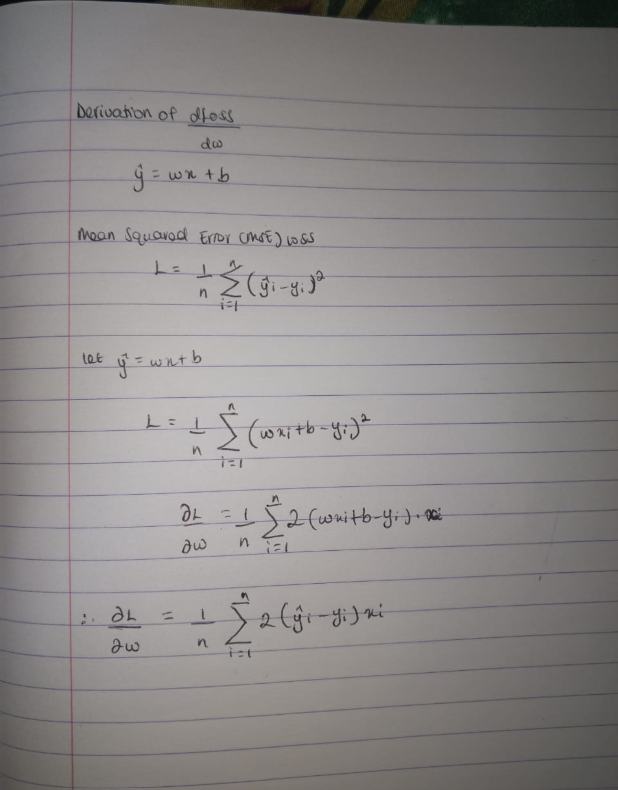
2. This is underfitting.
The model is too simple for the data.
A single neuron can only learn a straight line.
A sine wave is nonlinear, so no matter how lon the model is trained, the neuron will not be able to represent the curve.


Final loss:  0.19755190564138275


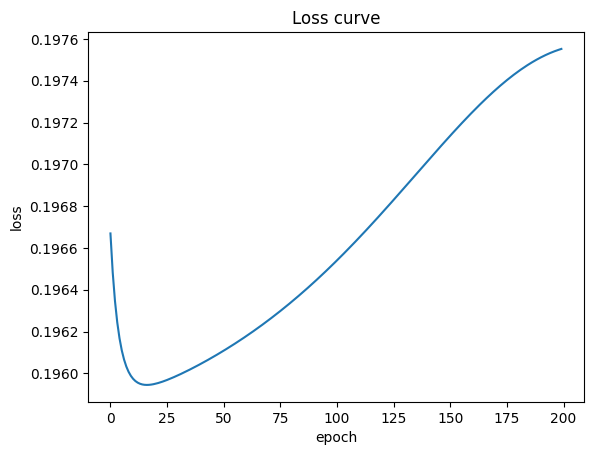

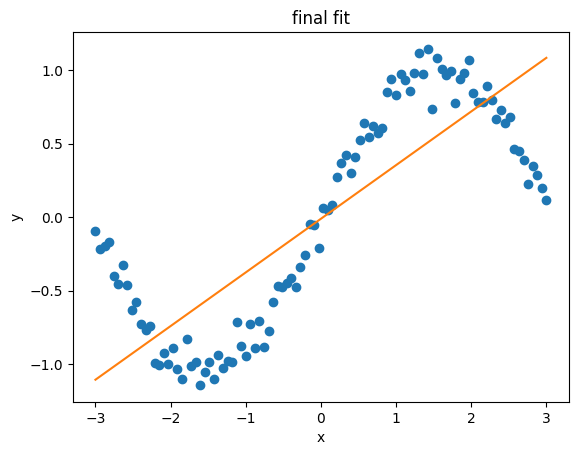

In [18]:
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

lr = 0.01
losses = []
for i in range(200):
  z1 = x @ W1 + b1
  h = z1
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat-y) ** 2)
  losses.append(loss)

  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

print("Final loss: ", losses[-1])

plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss curve')
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, y_hat)
plt.title('final fit')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Removing tanh causes the model to underfit because it becomes a linear model.
1. A stack of linear layers is still linear because the composition of linear function is another linear function. Without an activation function, multiple layers collapse into a single linear layer.
2. The 8 hidden neurons act as different nonlinear features that capture different parts of sine wave.
3. Backpropagation is an algorithm that uses the chain rule to calculate how each parameter contributed to the error and updates the weights to reduce the loss.


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2024/145183450.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat-y) ** 2)
/tmp/ipykernel_2024/145183450.py:20: RuntimeWarning: overflow encountered in matmul
  dh   = d_yhat @ W2.T
/tmp/ipykernel_2024/145183450.py:22: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


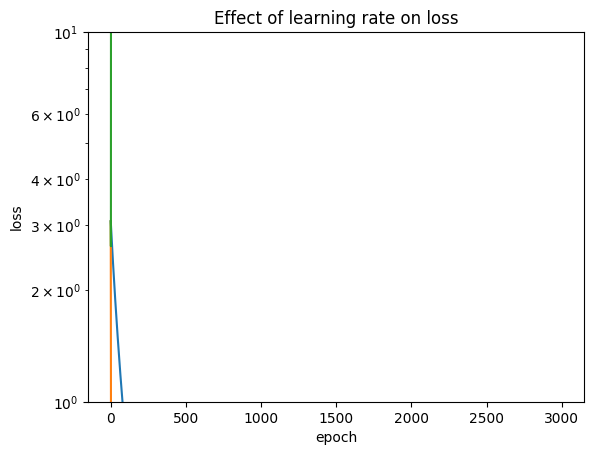

In [19]:
def train_toy(lr, steps=3000):
  np.random.seed(RANDOM_STATE)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)

  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)
  losses = []

  for i in range(steps):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat-y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    dh   = d_yhat @ W2.T

    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

  return losses

losses_1 = train_toy(0.001)
losses_2 = train_toy(0.05)
losses_3 = train_toy(1.0)

plt.plot(losses_1, label='lr=0.001')
plt.plot(losses_2, label='lr=0.05')
plt.plot(losses_3, label='lr=1.0')

plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("Effect of learning rate on loss")
plt.show()

The curve with lr = 0.001 decreases slowly because the weight updates are small, so learning takes longer.
The curve with lr = 0.05 decreases faster and converges well because the updates are large enough to update the model.
The curve with lr = 1.0 becomes unstable because the updates are too large, causing the model to overshoot the minimum and the loss to explode or oscillate.

A large learning rate does not simply make learning faster because gradient descent can jump past the optimal weights nstead of gradually moving toward them.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

print(obesity.head())
print(obesity.shape)


binary_cols = ['family_history_with_overweight',
               'FAVC',
               'SMOKE',
               'SCC']

for col in binary_cols:
  obesity[col] = obesity[col].map({'no': 0, 'yes': 1})

obesity['Gender'] = obesity['Gender'].map({'Female': 0, 'Male': 1})

obesity = pd.get_dummies(obesity, columns=['MTRANS', 'CAEC', 'CALC'])

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
X = obesity.drop('NObeyesdad', axis=1)
y = label_encoder.fit_transform(obesity['NObeyesdad'])

print(label_encoder.classes_)

x_train, x_temp, y_train, y_temp = train_test_split(X, y,
                                    test_size=0.4, stratify=y,
                                    random_state=RANDOM_STATE)

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp,
                                                test_size=0.5, stratify=y_temp,
                                                random_state=RANDOM_STATE)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(x_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train size: ", len(train_loader.dataset))
print("Validation size: ", len(val_loader.dataset))
print("Test size: ", len(test_loader.dataset))

print(x_train.shape)
print(y_train.shape)

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

1. CrossEntropyLoss in Pythorch expects integer class labels because it applies softmax internally and compares the predicted probabilities with correct class indexes. One-hot vectors uses a single integer to identify the correct class.
2. Neural networks are sensitive to feature scaling because the gradients depend on the input values. Random forests do not rely on gradients, so they are less affected by feature scale.
3. shuffle = True randomly changess the order of training samples in each epoch. This helpss produce a more stable and effective gradient updates during training.